### Dataset

In [1]:
#!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


### Dataset Name-Good and Rotten Apples

In [18]:
from roboflow import Roboflow
rf = Roboflow(api_key="DWkhqBMU6VvWaP5Glt64")
project = rf.workspace("universidadde-de-trsosmontes-e-alto-douro").project("rotten-apples-detection")
version = project.version(5)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rotten-apples-detection-5 in folder:: 100%|██████████| 904/904 [00:00<00:00, 8427.26it/s]


In [19]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
import matplotlib.pyplot as plt

In [20]:
### Setup basic Paths

base_dir='/content/Rotten-apples-detection-5'
train_dir=os.path.join(base_dir,'train')
val_dir=os.path.join(base_dir,'valid')


In [21]:
### 1. Load and preprocess data
img_size = 224
batch_size = 16

In [22]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [23]:
!cd Rotten-apples-detection-5

In [24]:
%cd /content/Rotten-apples-detection-5/train

/content/Rotten-apples-detection-5/train


In [25]:
!ls

'Good Apple'		   'Rotten Apple'
'Good Apple Rotten Apple'   Rotten-apples-detection-5


In [26]:
!rm -rf 'Good Apple Rotten Apple'

In [28]:
!rm -rf 'Rotten-apples-detection-5'

In [29]:
!ls

'Good Apple'  'Rotten Apple'


In [30]:
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)
val_gen=val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
)

Found 777 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [33]:
# 2. Load VGG16 base model

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable=False # Freeze convolutional base

# 3.  Add custom classification head
x=base_model.output
x=Flatten()(x)
x=Dense(128, activation='relu')(x)
x=Dropout(0.5)(x)

predictions=Dense(train_gen.num_classes, activation='sigmoid')(x)

In [34]:
model=Model(inputs=base_model.inputs, outputs=predictions)

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,338 (68.38 MB)

 Trainable params: 3,211,650 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [36]:
# 4. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [38]:
# 5. Train model
history=model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 32s 446ms/step - accuracy: 0.7053 - loss: 0.8338 - val_accuracy: 0.8100 - val_loss: 0.3233
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.7941 - loss: 0.4273 - val_accuracy: 0.9700 - val_loss: 0.1381
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.8147 - loss: 0.3840 - val_accuracy: 0.9900 - val_loss: 0.1189
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.8559 - loss: 0.2962 - val_accuracy: 0.9600 - val_loss: 0.1137
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.8674 - loss: 0.2952 - val_accuracy: 0.9600 - val_loss: 0.1335
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 255ms/step - accuracy: 0.8752 - loss: 0.2691 - val_accuracy: 0.9700 - val_loss: 0.0797
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - accuracy: 0.8777 - loss: 0.2706 - val_accuracy: 0.9800 - val_loss: 0.0688
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - accuracy: 0.8906 - loss: 0.2599 - val_accu

In [ ]:
# 6. Evaluate model
loss, acc=model.evaluate(val,gen)
print(f"Test Accuarcy:{Acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


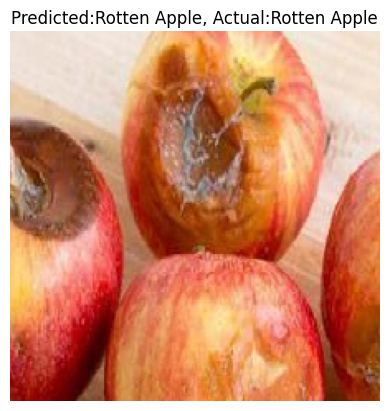

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


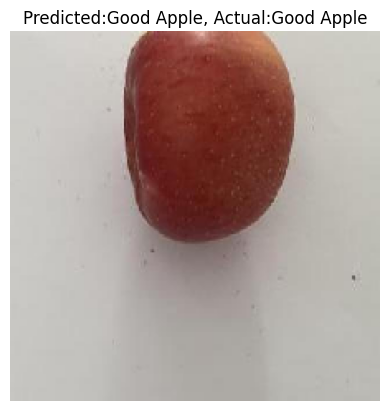

In [45]:
# 7. Inference: Predict and visualize some test images
class_labels = list(val_gen.class_indices.keys())

def plot_predictions(generator, model, num=5):
  for i in range(num):
    # use the built in next() function to get the next batch from the generator
    img, label = next(generator)
    pred = model.predict(img)
    plt.imshow(img[0])
    # apply np.argmax to the label of the first image in the batch(label[0])
    plt.title(f"Predicted:{class_labels[np.argmax(pred[0])]}, Actual:{class_labels[np.argmax(label[0])]}")
    plt.axis('off')
    plt.show()
plot_predictions(val_gen, model, num=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step


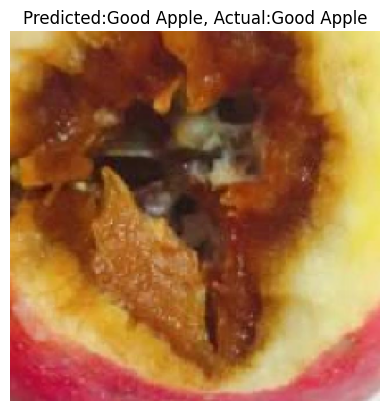

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


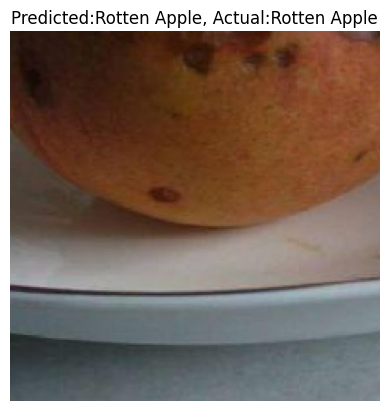

In [46]:
def plot_predictions(generator, model, num=5):
  for i in range(num):
    # use the built in next() function to get the next batch from the generator
    img, label = next(generator)
    pred = model.predict(img)
    plt.imshow(img[5])
    # apply np.argmax to the label of the first image in the batch(label[0])
    plt.title(f"Predicted:{class_labels[np.argmax(pred[0])]}, Actual:{class_labels[np.argmax(label[0])]}")
    plt.axis('off')
    plt.show()
plot_predictions(val_gen, model, num=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step


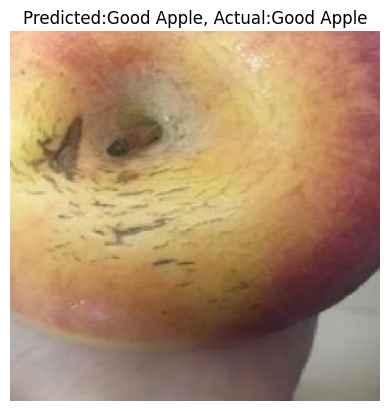

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


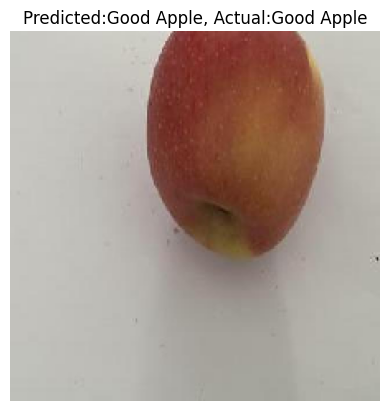

In [49]:
def plot_predictions(generator, model, num=5):
  for i in range(num):
    # use the built in next() function to get the next batch from the generator
    img, label = next(generator)
    pred = model.predict(img)
    plt.imshow(img[2])
    # apply np.argmax to the label of the first image in the batch(label[0])
    plt.title(f"Predicted:{class_labels[np.argmax(pred[0])]}, Actual:{class_labels[np.argmax(label[0])]}")
    plt.axis('off')
    plt.show()
plot_predictions(val_gen, model, num=2)